# Bonus — Final FastAPI, Correctness & Latency Notebook

This is the cleaned final Bonus notebook. It uses the frozen Phase 2 deployment artifacts, checks **offline/API equality**, benchmarks **200 HTTP requests**, and demonstrates one live prediction. A compatibility guard in `bonus_service.py` repairs the known `SimpleImputer._fill_dtype` fitted-state mismatch across scikit-learn minor versions without refitting or changing predictions.


**Run note:** this final notebook starts Uvicorn on a fresh free localhost port and writes `bonus/outputs/uvicorn_notebook_latest.log`. If startup fails, the real Uvicorn error is printed instead of a generic timeout.


In [1]:
from pathlib import Path
import sys, json, time, subprocess, requests, pandas as pd
import sklearn
from IPython.display import display

HERE = Path.cwd().resolve()
ROOT = next((p for p in [HERE, *HERE.parents] if (p / "phase1").exists() and (p / "bonus").exists()), None)
if ROOT is None:
    raise RuntimeError("Run from inside the extracted project folder")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Project root:", ROOT)
print("Python:", sys.executable)
print("scikit-learn:", sklearn.__version__)


Project root: D:\arshad\term2\MachinLearning\fainalProject\ML_final\ml_final_work
Python: d:\ml_final_venv\Scripts\python.exe
scikit-learn: 1.6.1


In [2]:
required = ROOT / "phase2" / "outputs" / "deployment_features.json"
if not required.exists():
    from phase2.final_defense_pipeline import run as run_phase2
    run_phase2(ROOT)
print("Deployment artifacts: READY")

Deployment artifacts: READY


## 1. Start the service and inspect health

In [3]:
import socket

def _free_local_port():
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind(("127.0.0.1", 0))
        return int(s.getsockname()[1])

# Always use a fresh local port. This avoids stale/hung processes left on 8001
# from an earlier interrupted notebook run.
SERVICE_PORT = _free_local_port()
SERVICE = f"http://127.0.0.1:{SERVICE_PORT}"
started_here = True
proc = None
log_handle = None
log_path = ROOT / "bonus" / "outputs" / "uvicorn_notebook_latest.log"
log_path.parent.mkdir(parents=True, exist_ok=True)

log_handle = open(log_path, "w", encoding="utf-8", buffering=1)
proc = subprocess.Popen(
    [
        sys.executable, "-m", "uvicorn", "bonus.bonus_service:app",
        "--host", "127.0.0.1", "--port", str(SERVICE_PORT),
        "--log-level", "info",
    ],
    cwd=str(ROOT),
    stdout=log_handle,
    stderr=subprocess.STDOUT,
)

last_error = None
deadline = time.time() + 60.0
while time.time() < deadline:
    # If Uvicorn crashed, show the real startup error instead of hiding it behind a timeout.
    if proc.poll() is not None:
        if log_handle is not None and not log_handle.closed:
            log_handle.flush()
            log_handle.close()
        details = log_path.read_text(encoding="utf-8", errors="replace") if log_path.exists() else "(no log)"
        raise RuntimeError(
            f"API process exited during startup (code={proc.returncode}).\n"
            f"--- uvicorn log ---\n{details[-6000:]}"
        )
    try:
        h = requests.get(SERVICE + "/health", timeout=1.0)
        if h.ok:
            health = h.json()
            break
    except Exception as exc:
        last_error = repr(exc)
    time.sleep(0.5)
else:
    if proc is not None and proc.poll() is None:
        proc.terminate()
        try:
            proc.wait(timeout=5)
        except subprocess.TimeoutExpired:
            proc.kill()
    if log_handle is not None and not log_handle.closed:
        log_handle.flush()
        log_handle.close()
    details = log_path.read_text(encoding="utf-8", errors="replace") if log_path.exists() else "(no log)"
    raise RuntimeError(
        "API did not become healthy within 60 seconds.\n"
        f"Last HTTP error: {last_error}\n"
        f"--- uvicorn log ---\n{details[-6000:]}"
    )

print("SERVICE:", SERVICE)
print(json.dumps(health, indent=2))


RuntimeError: API process exited during startup (code=1).
--- uvicorn log ---
ERROR:    Error loading ASGI app. Could not import module "bonus.bonus_service".


## 2. Offline/API correctness report

In [ ]:
from bonus.bonus_latency import correctness_check, benchmark

correct_detail, correct_summary = correctness_check(base_url=SERVICE, n_cases=12)
display(correct_detail)
print(json.dumps(correct_summary, indent=2))
assert correct_summary["all_pass"]
print("Offline/API correctness: 12/12 PASS")


 match_id  snapshot_minute  max_probability_abs_diff  margin_abs_diff  pass
  3773593                0                       0.0              0.0  True
  3773466               15                       0.0              0.0  True
  3773672               30                       0.0              0.0  True
  3773587               45                       0.0              0.0  True
  3773585               60                       0.0              0.0  True
  3773386               75                       0.0              0.0  True
  3773477               90                       0.0              0.0  True
  3773656                0                       0.0              0.0  True
  3773547               15                       0.0              0.0  True
  3773660               30                       0.0              0.0  True
  3773523               45                       0.0              0.0  True
  3773377               60                       0.0              0.0  True

{
  "n_cases": 12,
  "all_pass": true,
  "max_probability_abs_diff": 0.0,
  "max_margin_abs_diff": 0.0
}
Offline/API correctness: 12/12 PASS


## 3. 200-request end-to-end HTTP latency report

{
  "n_requests": 200,
  "successful": 200,
  "error_rate": 0.0,
  "mean_ms": 1.64930812,
  "p50_ms": 1.6233865,
  "p95_ms": 1.8357175499999998,
  "p99_ms": 2.0278550899999996,
  "max_ms": 2.083807,
  "requirement_ms": 200.0,
  "pass_p95_under_200ms": true,
  "pass_p99_under_200ms": true
}


,n_requests,successful,error_rate,mean_ms,p50_ms,p95_ms,p99_ms,max_ms,requirement_ms,pass_p95_under_200ms,pass_p99_under_200ms
0,200,200,0.0,1.649,1.623,1.836,2.028,2.084,200.0,True,True


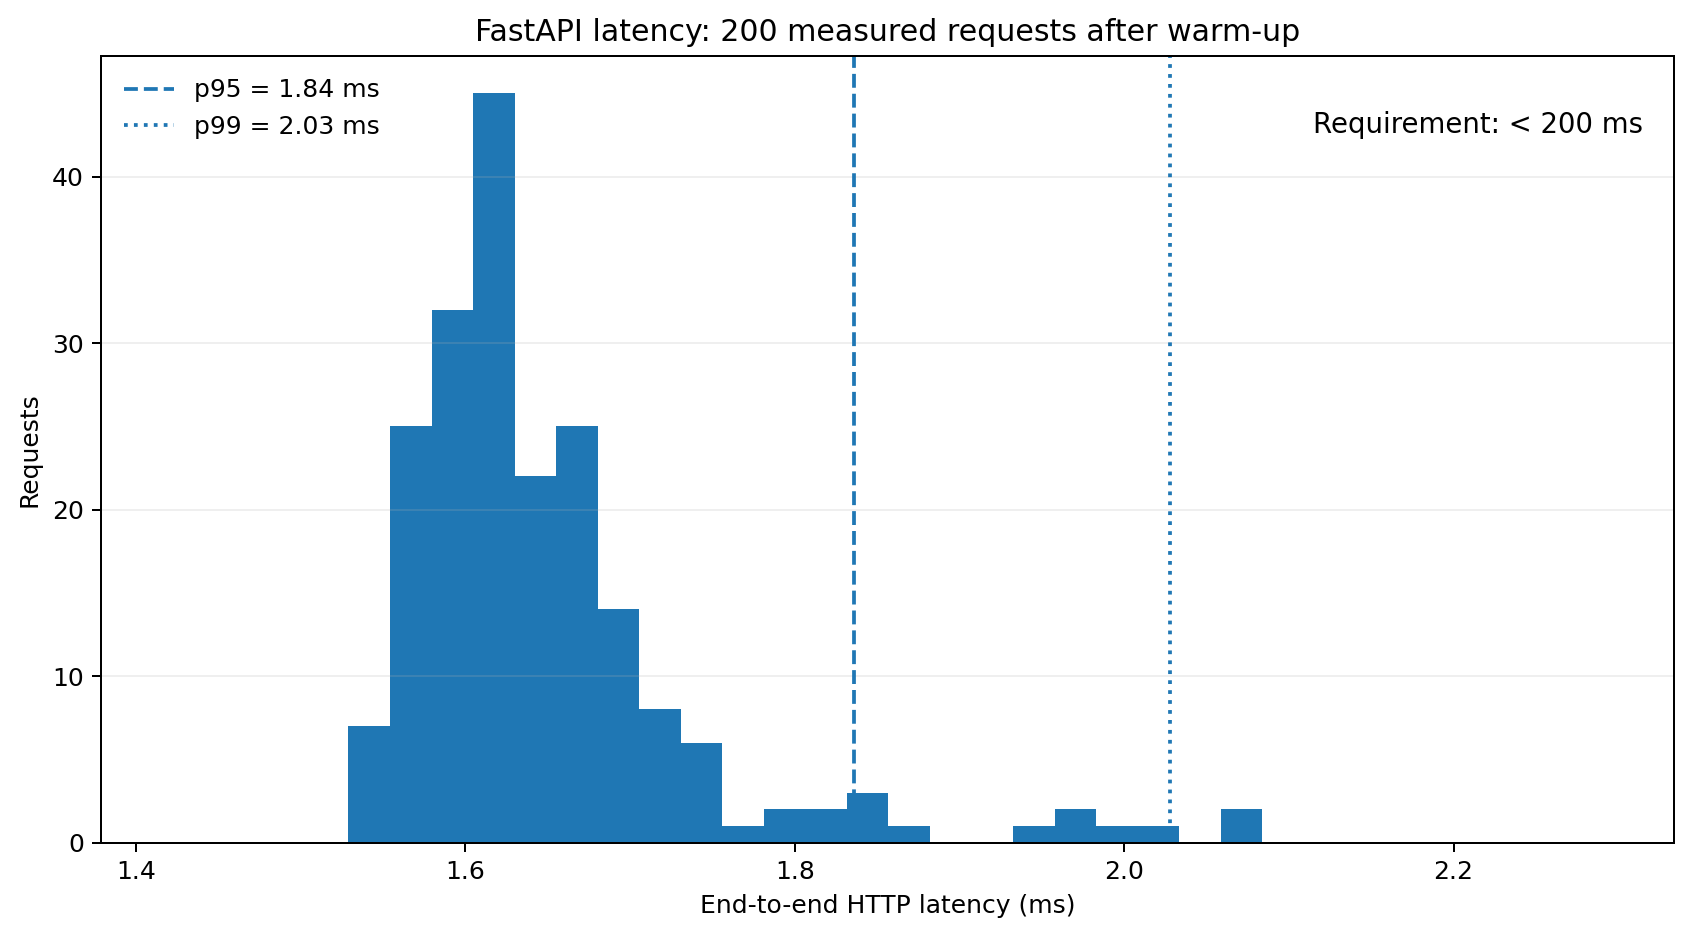

<200 ms requirement: PASS


In [ ]:
lat_detail, lat_summary = benchmark(base_url=SERVICE, n_requests=200, warmup=20)
display(pd.DataFrame([lat_summary]).round(3))
assert lat_summary["successful"] == 200
assert lat_summary["p95_ms"] < 200
print("<200 ms requirement: PASS")


## 4. Hand-crafted live request with SHAP attributions

In [ ]:
pre = pd.read_csv(ROOT / "phase1" / "outputs" / "pre_match_features_final.csv")
mid = int(pre.loc[pre.season.eq("2020/2021"), "match_id"].iloc[-1])
response = requests.post(SERVICE + "/predict", json={"match_id": mid, "snapshot_minute": 60}, timeout=5)
response.raise_for_status()
print(json.dumps(response.json(), indent=2))

{
  "match_id": 3773457,
  "snapshot_minute": 60,
  "actual_minute": 60,
  "model_used": "in_play",
  "probabilities": {
    "H": 0.8096995269730299,
    "D": 0.1485522225417043,
    "A": 0.0417482504852658
  },
  "expected_margin": 0.8604466280056248,
  "top_shap": {
    "diff_form5_xg_for_final": 0.6774124706381364,
    "diff_form5_carries_final_third_final": 0.6184334295330818,
    "diff_form5_event_share_final": 0.4922780467328003,
    "diff_form5_goals_for_final": 0.32473502259108084,
    "diff_form5_points_final": 0.23687931590087016
  }
}


## 5. Stop the notebook-started service

In [ ]:
if started_here and proc is not None:
    if proc.poll() is None:
        proc.terminate()
        try:
            proc.wait(timeout=5)
        except subprocess.TimeoutExpired:
            proc.kill()
    if log_handle is not None and not log_handle.closed:
        log_handle.flush()
        log_handle.close()
    print("Service stopped.")
    print("Uvicorn log:", log_path)
else:
    print("No notebook-started service to stop.")


Service stopped.


### Dashboard
Run from the project root after the API is started:

```bash
python -m uvicorn bonus.bonus_service:app --host 127.0.0.1 --port 8001
streamlit run bonus/bonus_dashboard.py
```


In [ ]:
print("BONUS_OK")

BONUS_OK
